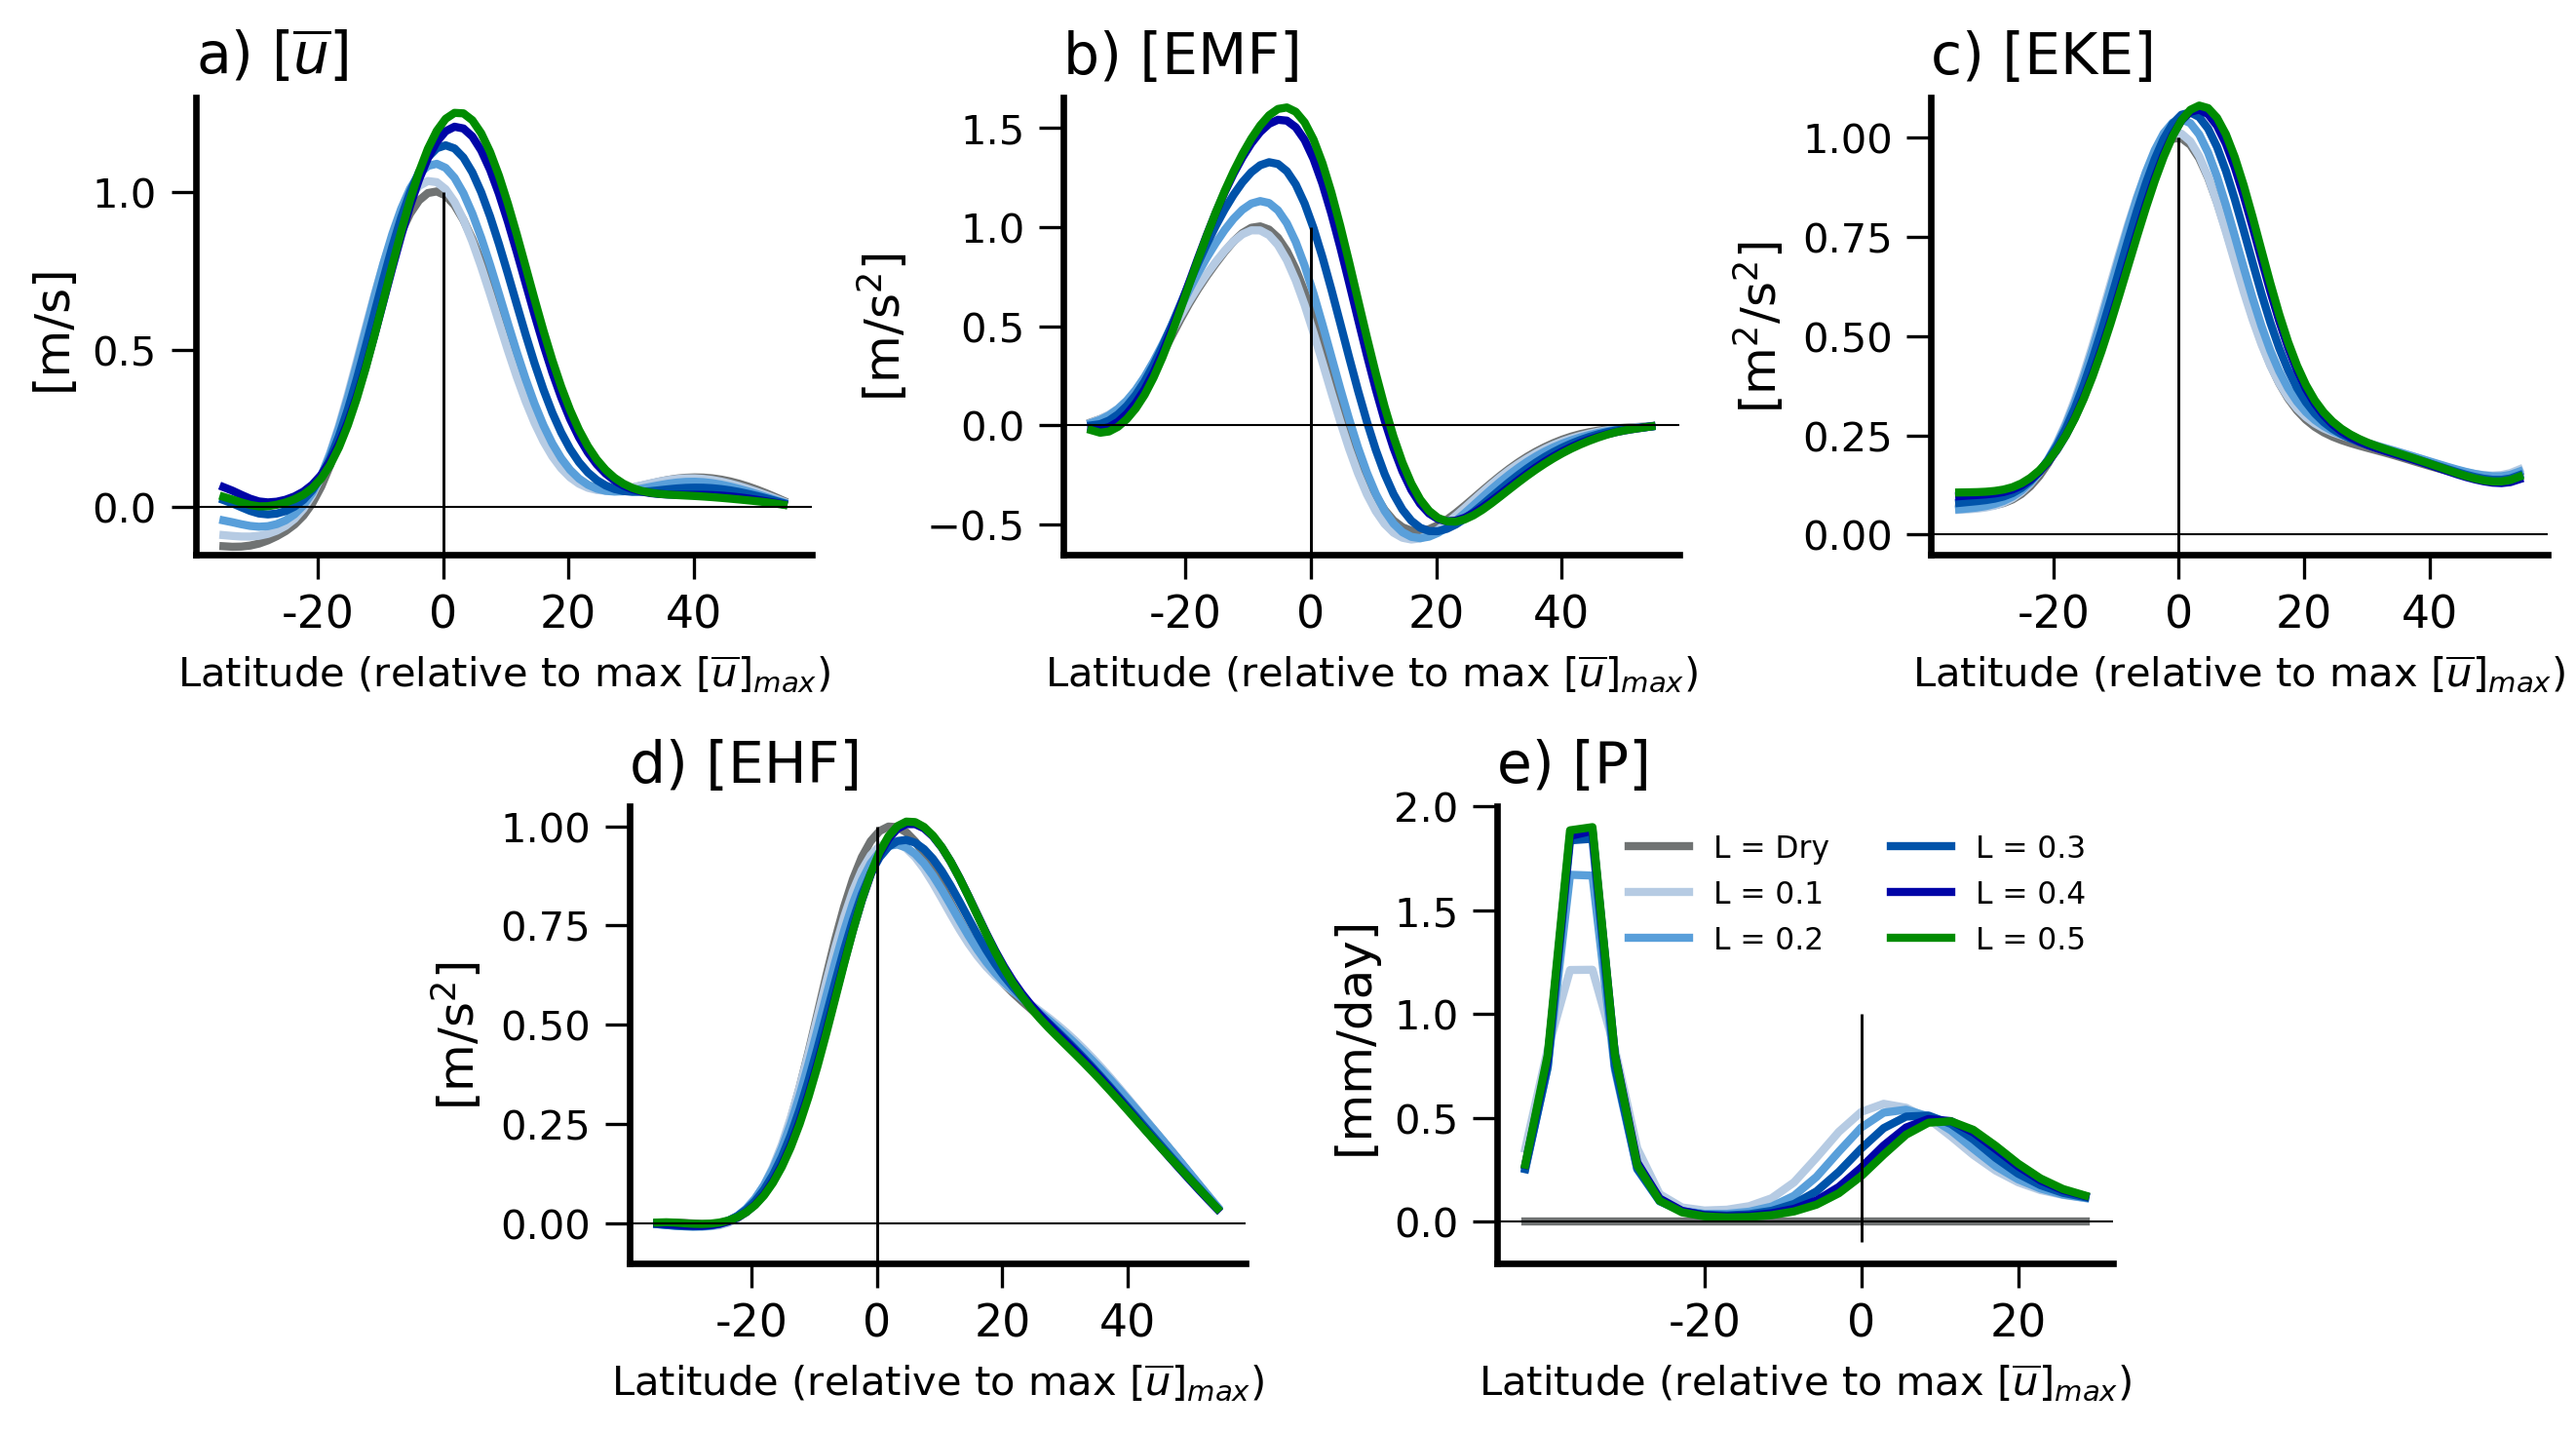

In [222]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import matplotlib as mpl
from scipy.interpolate import interp1d

# Initialize plotting
fig = plt.figure(figsize=(9, 5), dpi=300)
mpl.rcParams['axes.linewidth'] = 1.6

# Define grid layout for subplots
spec = mpl.gridspec.GridSpec(ncols=6, nrows=2)
ax1 = fig.add_subplot(spec[0, 0:2])
ax2 = fig.add_subplot(spec[0, 2:4])
ax3 = fig.add_subplot(spec[0, 4:])
ax4 = fig.add_subplot(spec[1, 1:3])
ax5 = fig.add_subplot(spec[1, 3:5])

# Parameters
PR_values = [0, 10, 20, 30, 40, 50]
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218], 
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0
latitudes = np.linspace(-90, 90, 64)  # Assuming 64 latitude points
relative_latitudes = latitudes[32:]  # Focus on the subset (adjust as per your data)

# Interpolation parameters
apply_interpolation = True  # Set to False to skip interpolation
interpolation_times = 2
new_time_points = len(relative_latitudes) * interpolation_times if apply_interpolation else len(relative_latitudes)
y_new = np.linspace(-90, 90, len(latitudes) * interpolation_times) if apply_interpolation else latitudes
new_times = np.linspace(0, len(relative_latitudes) - 1, new_time_points) if apply_interpolation else np.arange(len(relative_latitudes))

# Storage arrays for interpolated data
u_all_interpolated = np.zeros((len(PR_values), new_time_points))
emf_interpolated = np.zeros((len(PR_values), new_time_points))
ehf_interpolated = np.zeros((len(PR_values), new_time_points))
eke_interpolated = np.zeros((len(PR_values), new_time_points))
prec_interpolated = np.zeros((len(PR_values), new_time_points))

# Placeholder for latitude of maximum wind for PR=0
y_pr0 = None

# Process each PR value
for i, PR in enumerate(PR_values):
    # if PR == 40:
    #     pass
    # else:
        u_file_path    = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/u/u_climatology.h5"
        flux_file_path = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/flux_and_precipitation/flux_and_prec_climatology_PR{PR}.h5"

        with h5py.File(u_file_path, 'r') as u_file:
            u_data = u_file["u_climatology"][32:]
        with h5py.File(flux_file_path, 'r') as flux_file:
            emf_data = flux_file["EMF"][32:]
            ehf_data = flux_file["EHF"][32:]
            eke_data = flux_file["EKE"][32:]
            prec_data = flux_file["prec"][29:-9]
    
            # Find latitude of maximum u wind for PR=0
            if PR == 0:
                u_dry_max_index = np.argmax(u_data)
                y_pr0 = relative_latitudes[u_dry_max_index]
                max_u, max_emf, max_ehf, max_eke, max_prec = map(np.max, [u_data, emf_data, ehf_data, eke_data, prec_data])
    
            # Normalize data by max values for PR=0
            u_normalized = u_data / max_u
            emf_normalized = emf_data / max_emf
            ehf_normalized = ehf_data / max_ehf
            eke_normalized = eke_data / max_eke
            prec_normalized = prec_data / max_prec
    
            if apply_interpolation:
                # Interpolate the data
                u_interpolator = interp1d(np.arange(len(relative_latitudes)), u_normalized, kind='cubic')
                emf_interpolator = interp1d(np.arange(len(relative_latitudes)), emf_normalized, kind='cubic')
                ehf_interpolator = interp1d(np.arange(len(relative_latitudes)), ehf_normalized, kind='cubic')
                eke_interpolator = interp1d(np.arange(len(relative_latitudes)), eke_normalized, kind='cubic')
    
                u_all_interpolated[i] = u_interpolator(new_times)
                emf_interpolated[i] = emf_interpolator(new_times)
                ehf_interpolated[i] = ehf_interpolator(new_times)
                eke_interpolated[i] = eke_interpolator(new_times)
            else:
                # Use data without interpolation
                u_all_interpolated[i] = u_normalized
                emf_interpolated[i] = emf_normalized
                ehf_interpolated[i] = ehf_normalized
                eke_interpolated[i] = eke_normalized
    
            # Plot data for subplots
            y_relative = y_new[len(latitudes) * interpolation_times // 2:] - y_pr0 if apply_interpolation else relative_latitudes - y_pr0
            ax1.plot(y_relative, u_all_interpolated[i], color=colors[i], lw=2)
            ax2.plot(y_relative, emf_interpolated[i], color=colors[i], lw=2)
            ax3.plot(y_relative, eke_interpolated[i], color=colors[i], lw=2)
            ax4.plot(y_relative, ehf_interpolated[i], color=colors[i], lw=2)
    
            # Precipitation plot
            if PR == 0:
                ax5.plot(latitudes[29:-9] - y_pr0, prec_normalized * 0, color=colors[i], lw=2, label=f"L = Dry")
            else:
                ax5.plot(latitudes[29:-9] - y_pr0, prec_normalized, color=colors[i], lw=2, label=f"L = {PR * 0.01}")

# Set titles, labels, and legends
titles = [r"a) [$\overline{u}$]", r"b) [EMF]", r"c) [EKE]", r"d) [EHF]", "e) [P]"]
axes = [ax1, ax2, ax3, ax4, ax5]
y_labels = ["[m/s]", "[m/s$^2$]", "[m$^2$/s$^2$]", "[m/s$^2$]", "[mm/day]"]
desired_latitudes      = np.array([-20,  0, 20, 40])  # This should be defined based on your specific needs

for i, ax in enumerate(axes):
    ax.axhline(y=0, color="black", lw=0.5)
    ax.set_title(f"{titles[i]}", loc="left", fontsize=14)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.set_xticks(desired_latitudes)  # This sets where the ticks will appear

    if i <= 4:
        ax.set_ylabel(y_labels[i], fontsize=12)
    ax.tick_params(axis='x', labelsize=11)
    ax.set_xlabel("Latitude (relative to max $[\overline{u}]_{max}$)", fontsize=10)

    ax.tick_params(direction='out', length=6)#, colors='r',
                   #grid_color='r', grid_alpha=0.5)
    ax.set_xticklabels([str(int(lat)) for lat in desired_latitudes])

# Final adjustments
### cross line
ax1.vlines(0, ymin=-0.65,ymax=1, colors="black", linewidth=0.7)
ax1.set_ylim([-0.15,1.3])

ax2.vlines(0, ymin=-0.65,ymax=1, colors="black", linewidth=0.7)
ax2.set_ylim([-0.65,1.65])

ax3.vlines(0, ymin=-0.1,ymax=1, colors="black", linewidth=0.7)
ax3.set_ylim([-0.05,1.1])

ax4.vlines(0, ymin=-0.1,ymax=1, colors="black", linewidth=0.7)
ax4.set_ylim([-0.1,1.05])

ax5.vlines(0, ymin=-0.1,ymax=1, colors="black", linewidth=0.7)

ax5.legend(loc="best", prop={'size': 7.5}, frameon=False, ncols=2)
plt.tight_layout()
plt.show()


Midlatitude range: [30.         32.85714286 35.71428571 38.57142857 41.42857143 44.28571429
 47.14285714 50.        ]
Wind shear shape: (19500, 64)
Wind shear shape: (19500, 64)
Wind shear shape: (19500, 64)
Wind shear shape: (19500, 64)
Wind shear shape: (19500, 64)
Wind shear shape: (19500, 64)


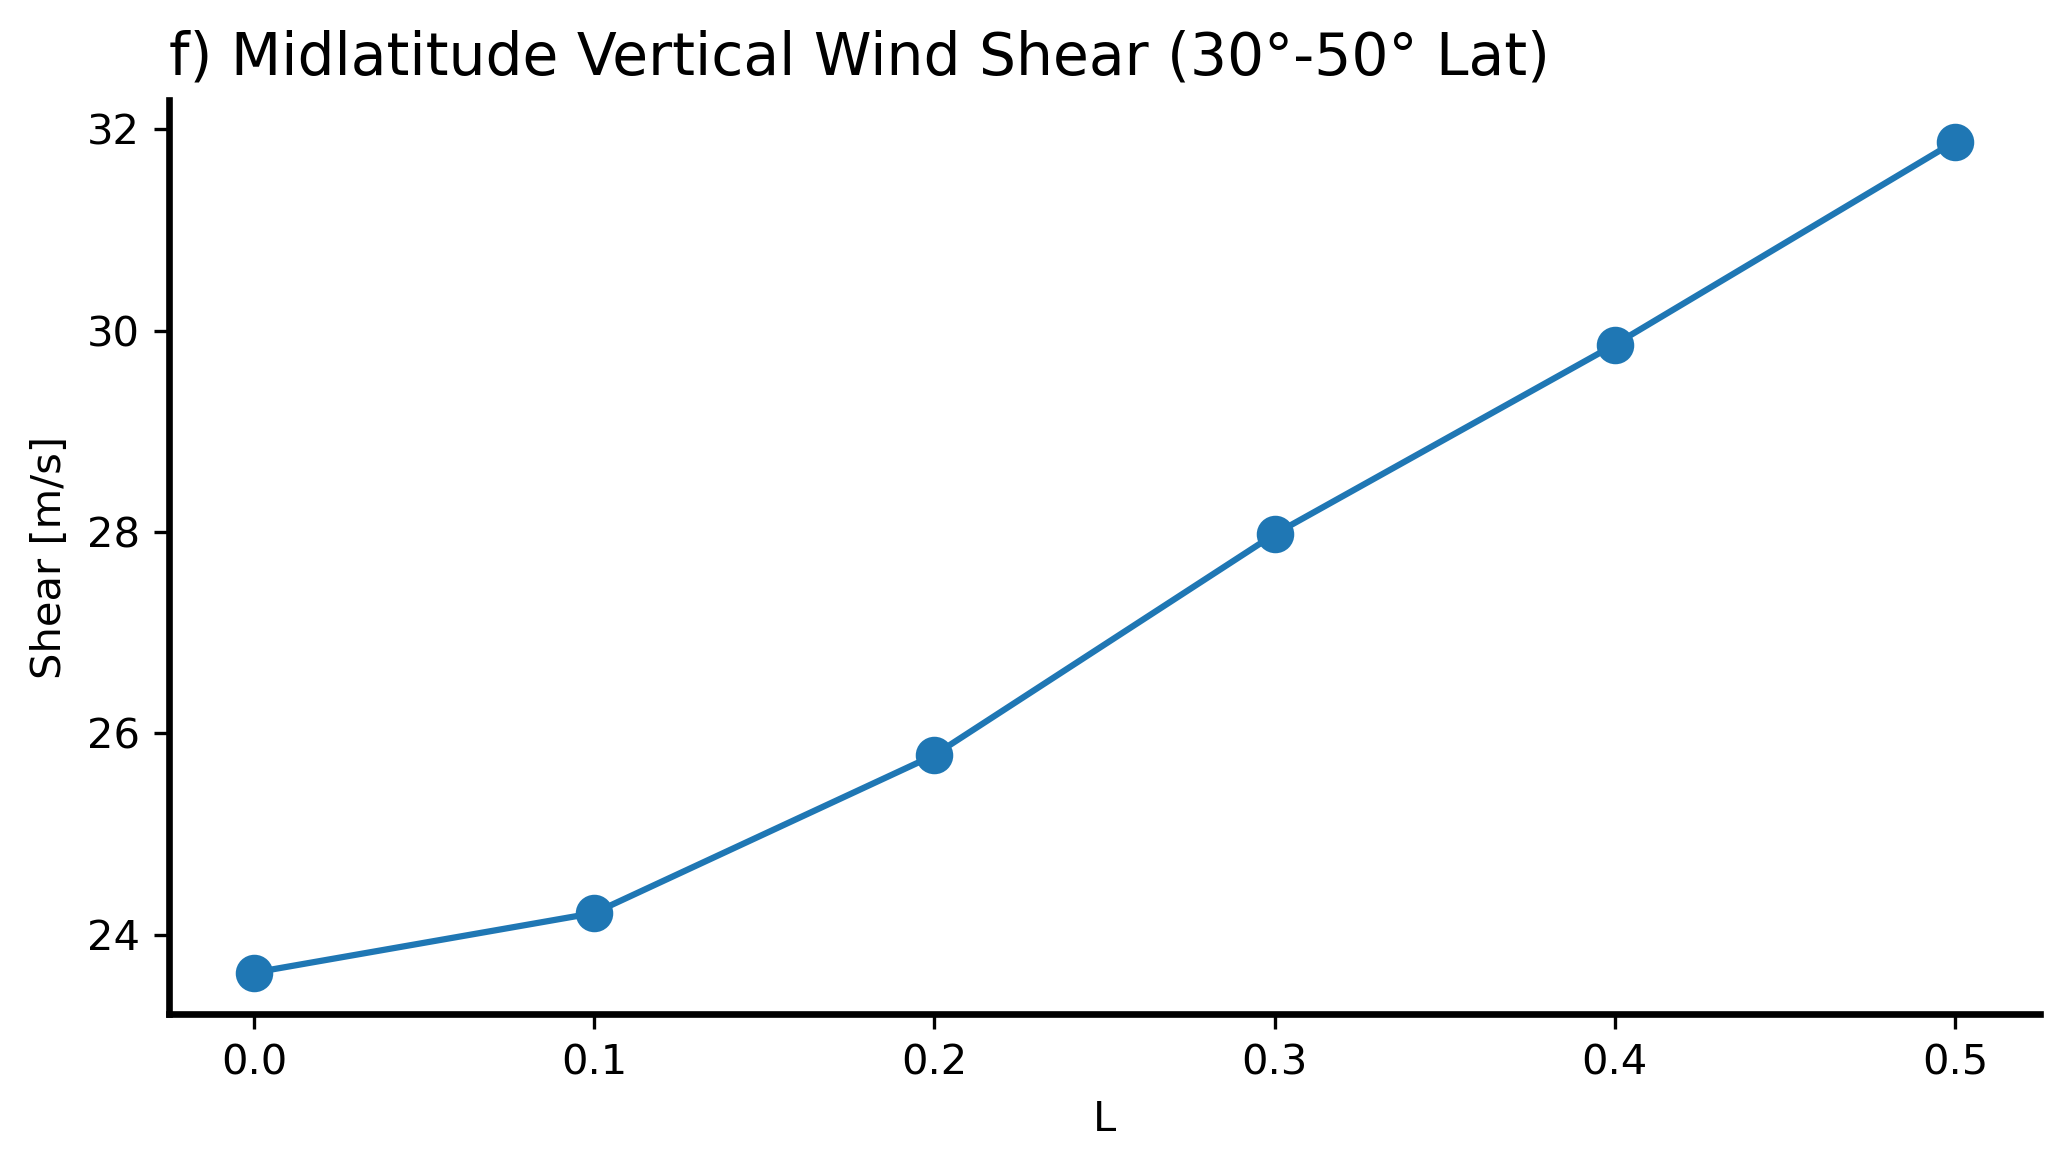

In [223]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

# Parameters
PR_values = np.array([0, 10, 20, 30, 40, 50])  # Convert to NumPy array for numerical operations
vertical_shear_midlat = []

# Define midlatitude indices
latitudes = np.linspace(-90, 90, 64)  # Assuming 64 latitude points in the data
midlat_indices = (latitudes >= 30) & (latitudes <= 50)  # Correctly match the size of latitude
print("Midlatitude range:", latitudes[midlat_indices])

for PR in PR_values:
    # Load data for the specific PR value
    file_path = f"/data92/PeterChang/1120_preprocessing/PR{PR}/variability/u/u_PR{PR}_yzt.h5"
    with h5py.File(file_path, 'r') as U_file:
        u_zm_data = U_file["u"][:, :, :]  # Extract data

    # Reshape to daily means (time, y, z)
    u_zm_daily = u_zm_data.reshape((19500, 4, 20, 64)).mean(axis=1)
    
    # Calculate vertical wind shear for midlatitudes
    wind_shear = u_zm_daily[:, 3, :] - u_zm_daily[:, -1, :]  # Shear between level 3 and level -1
    print("Wind shear shape:", wind_shear.shape)
    shear_midlat = wind_shear[:, midlat_indices].mean(axis=(0, 1))  # Average over midlatitude range
    vertical_shear_midlat.append(shear_midlat)

# Plotting
fig, ax = plt.subplots(1, figsize=(7, 4), dpi=300)
ax.plot(PR_values * 0.01, vertical_shear_midlat, linestyle='-', marker='o', markersize=8, label="Vertical Wind Shear")

# Customize plot
ax.set_title("f) Midlatitude Vertical Wind Shear (30°-50° Lat)", loc="left", fontsize=14)
ax.set_xlabel("L", fontsize=10)
ax.set_ylabel("Shear [m/s]", fontsize=10)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()


In [153]:
shear_midlat.min()

6.87661992265785

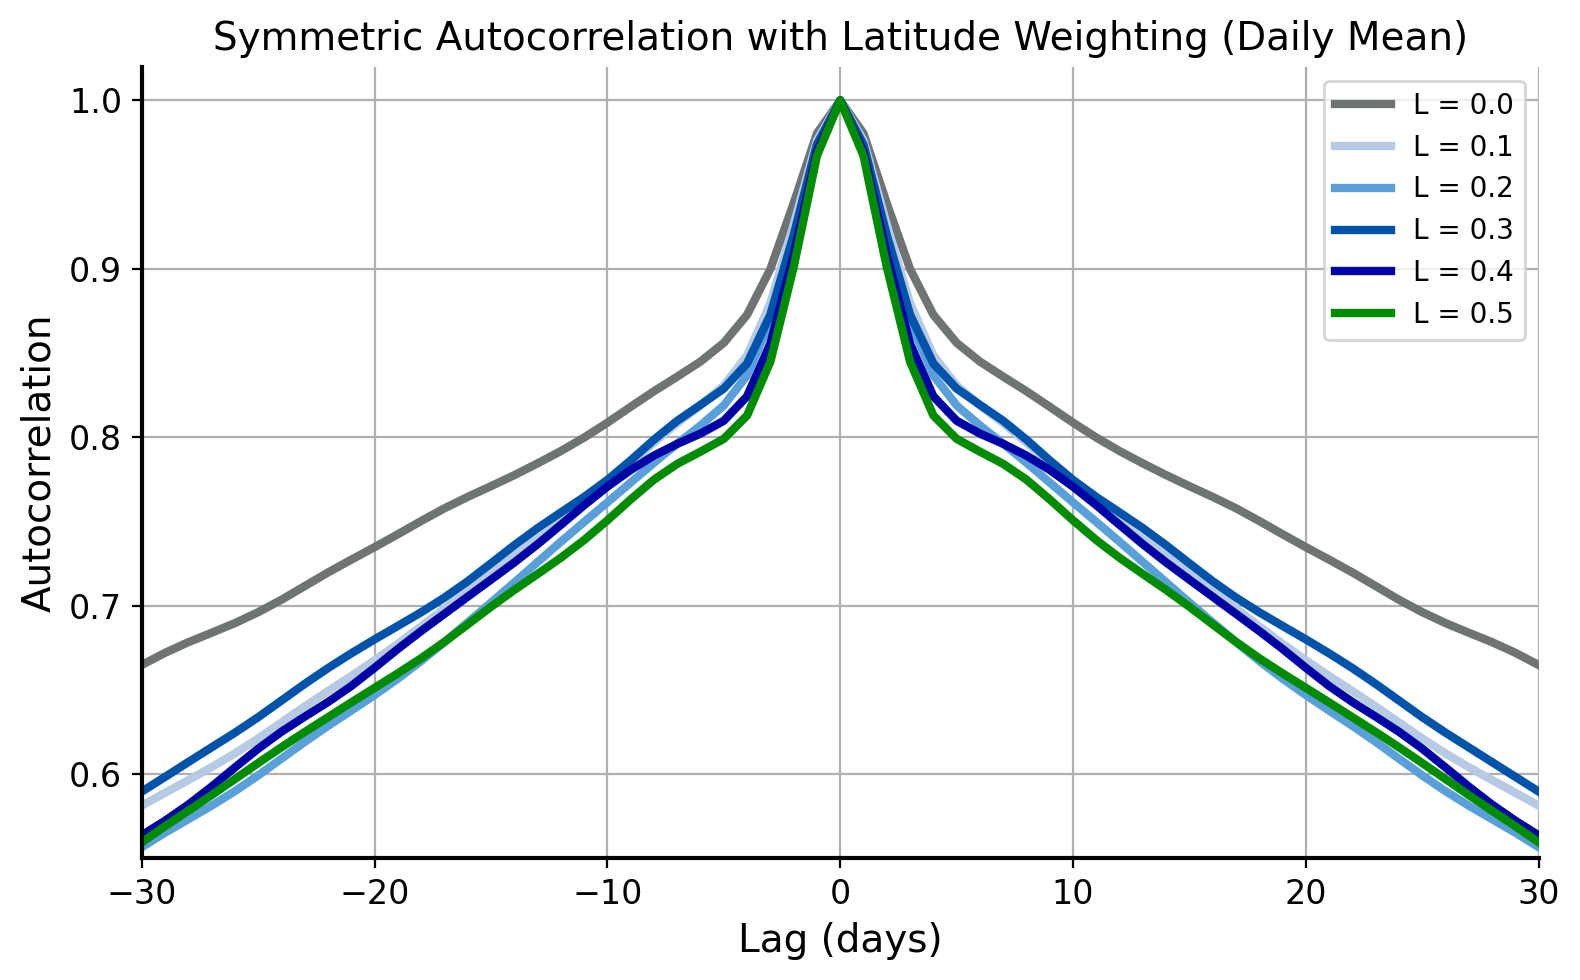

In [228]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

sys.path.append("back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/")
from EOF import EOF


class Moist_Dycore_Package:
    def __init__(self, zonal_dimension: int = 3):
        self.zonal_dimension = zonal_dimension

    def zonal_mean(self, data):
        return np.mean(data, axis=self.zonal_dimension, keepdims=True)

    def zonal_anomaly(self, data):
        mean = self.zonal_mean(data)
        np.subtract(data, mean, out=data)
        return data

    def load_data(self, file_path, variable_name):
        with h5py.File(file_path, "r") as file:
            return np.array(file[variable_name], dtype=np.float32)

    def calculate_daily_mean(self, data):
        """
        Calculate daily mean data from 6-hourly data.
        Assumes the time dimension is the first axis.
        """
        num_days = data.shape[0] // 4  # Calculate number of days
        daily_mean = data[:num_days * 4].reshape(num_days, 4, -1).mean(axis=1)
        return daily_mean

    def calculate_EOF_with_custom_class(self, input_data, latitudes, n_components: int = 32, field: str = "2D"):
        weights = np.sqrt(np.cos(np.radians(latitudes)))
        weighted_data = input_data * weights

        eof_instance = EOF((weighted_data,), n_components=n_components, field=field)
        eof_instance.get()

        EOF_modes = eof_instance.EOF[:2]
        PCs = eof_instance.PC[0]
        explained_variance = eof_instance.explained

        PCs_normalized = PCs / PCs.std(axis=0)

        return EOF_modes, PCs_normalized, explained_variance

    def symmetric_autocorr(self, x, max_lag, split_to_chunk, window_length, overlap=250):
        if not split_to_chunk:
            corr = np.zeros(2 * max_lag + 1)
            for l in range(-max_lag, max_lag + 1):
                if l == 0:
                    corr[l + max_lag] = 1.0
                elif l > 0:
                    corr[l + max_lag] = np.corrcoef(x[l:], x[:-l])[0][1]
                else:
                    corr[l + max_lag] = np.corrcoef(x[:l], x[-l:])[0][1]
            return corr
        else:
            step_size = window_length - overlap
            num_windows = (len(x) - overlap) // step_size
            corr = np.zeros((num_windows, 2 * max_lag + 1))

            for i in range(num_windows):
                start = i * step_size
                end = start + window_length
                x_window = x[start:end]

                if len(x_window) < window_length:
                    break

                for l in range(-max_lag, max_lag + 1):
                    if l == 0:
                        corr[i, l + max_lag] = 1.0
                    elif l > 0:
                        corr[i, l + max_lag] = np.corrcoef(x_window[l:], x_window[:-l])[0, 1]
                    else:
                        corr[i, l + max_lag] = np.corrcoef(x_window[:l], x_window[-l:])[0, 1]

            return corr.mean(axis=0)


# Initialize the Package
moist_dycore = Moist_Dycore_Package(zonal_dimension=3)

# Parameters
PR_values = [0, 10, 20, 30, 40, 50]
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218],
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0
auto_length = 100
window_length = 500
split_to_chunk = False
latitudes = np.linspace(0, 90, 32)

# Load data, calculate daily mean, and compute PC1 for all PR values
PC1_all  = []
EOFs_all = []


for PR in PR_values:
    file_path = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5"
    variable_name = "u"
    u_data = moist_dycore.load_data(file_path, variable_name)
    
    # Calculate daily mean
    u_daily = moist_dycore.calculate_daily_mean(u_data)
    
    # Use the custom EOF class
    EOFs, PC_normalized, _ = moist_dycore.calculate_EOF_with_custom_class(u_daily[:, 32:], latitudes, n_components=32, field="1D")
    EOFs_all.append(EOFs[:])  # Extract normalized PC1 for the current PR value
    PC1_all.append(PC_normalized[:])  # Extract normalized PC1 for the current PR value
    

PC1_all  = np.array(PC1_all)
EOFs_all = np.array(EOFs_all)


# Calculate symmetric autocorrelation for PC1
autocorr_results = []
for i in range(len(PR_values)):
    autocorr_results.append(
        moist_dycore.symmetric_autocorr(PC1_all[i, :], auto_length, split_to_chunk, window_length)
    )

# tau for plotting
tau_full = np.arange(-auto_length, auto_length + 1)

# Plot the symmetric autocorrelation
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for i, PR in enumerate(PR_values):
    ax.plot(tau_full, autocorr_results[i], label=f"L = {PR * 0.01}", color=colors[i], lw=3)

# Customize plot
ax.set_title("Symmetric Autocorrelation with Latitude Weighting (Daily Mean)", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
plt.ylim([0.55, 1.02])
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


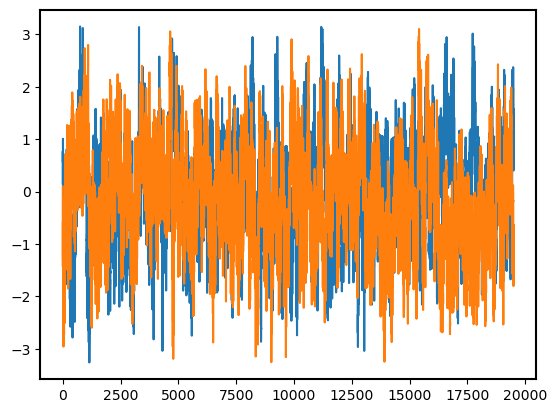

In [229]:
plt.figure()
for i in [3,4]:
    plt.plot(PC1_all[i])

In [173]:
# Uzm_6hourly_all = np.zeros((78000, 64))
Uzm_all = np.zeros((6, 19500, 64))
# num_days = Uzm_6hourly_all.shape[0] // 4  # Ensure divisible by 4

a = 0
for PR in [0,10,20,30,40,50]:
    # Uzm_6hourly_all = read_var_at_level(PR, "grid_u_c_xyzt", 500, 20000, 0) 
    # Reshape the data: group every 4 time steps (6-hourly) into one day
    # if PR ==40:
    #     Uzm_all[a] = np.zeros((19500, 64))
    # else:
        with h5py.File(f"/data92/PeterChang/1120_preprocessing//PR{PR}/climatology/u_add_time_dim/u_climatology_add_time_dim.h5") as f:
            Uzm_all[a] = f["u"][:,:].reshape(19500,4,64).mean(axis=1)
        # print(
        a += 1

In [174]:
EMF = np.zeros((6, 19500, 64))
aa = 0
for PR in range(0, 60, 10):
    # if PR == 40:
    #     pass
    # else:
        EMF_file = f"/data92/PeterChang/1120_preprocessing/PR{PR}/climatology/EMF_add_time_dim/EMF_climatology_add_time_dim.h5"
        with h5py.File(EMF_file,'r') as f :
            EMF[aa] = f["EMF"][:,:].reshape(19500,4,64).mean(axis=1)
        aa += 1

In [175]:
radius  = 6.37122e6
y = np.linspace(-90,90,64)
yd = np.deg2rad(y)
cy = np.cos(yd)
cy2 = cy **2

sigma_onlyz = np.linspace(0,1,20)
yy, sigma_mean2 = np.meshgrid(y, sigma_onlyz)

dmdy = np.zeros((6, 19500, 64))
for a in range(6):
    Mzm = EMF[a] # EMF_oringin_grid[a]
    print(Mzm.shape)
    
    for i in range(1,64-1):
        dmdy[a,:,i] = -(Mzm[:,i+1] * (cy[i]**2) - Mzm[:,i-1]* (cy[i]**2)) / (radius * (cy[i]**2) * (yd[i+1] - yd[i-1]))
    # dmdy[a,:,:,1:-1] = -((Mzm[:,:,2:] - Mzm[:,:,:-2]) * cy2[1:-1]) / (radius * (cy2[1:-1]) * (yd[2:] - yd[:-2]))
    
    dmdy[a,:, 0] = -((Mzm[:, 1] - Mzm[:, 0]) * cy2[0])  / (radius* cy2[0]  *(yd[ 1] - yd[ 0]))
    dmdy[a,:,-1] = -((Mzm[:,-1] - Mzm[:,-2]) * cy2[-1]) / (radius* cy2[-1] *(yd[-1] - yd[-2]))
print(dmdy.shape)



(19500, 64)
(19500, 64)
(19500, 64)
(19500, 64)
(19500, 64)
(19500, 64)
(6, 19500, 64)


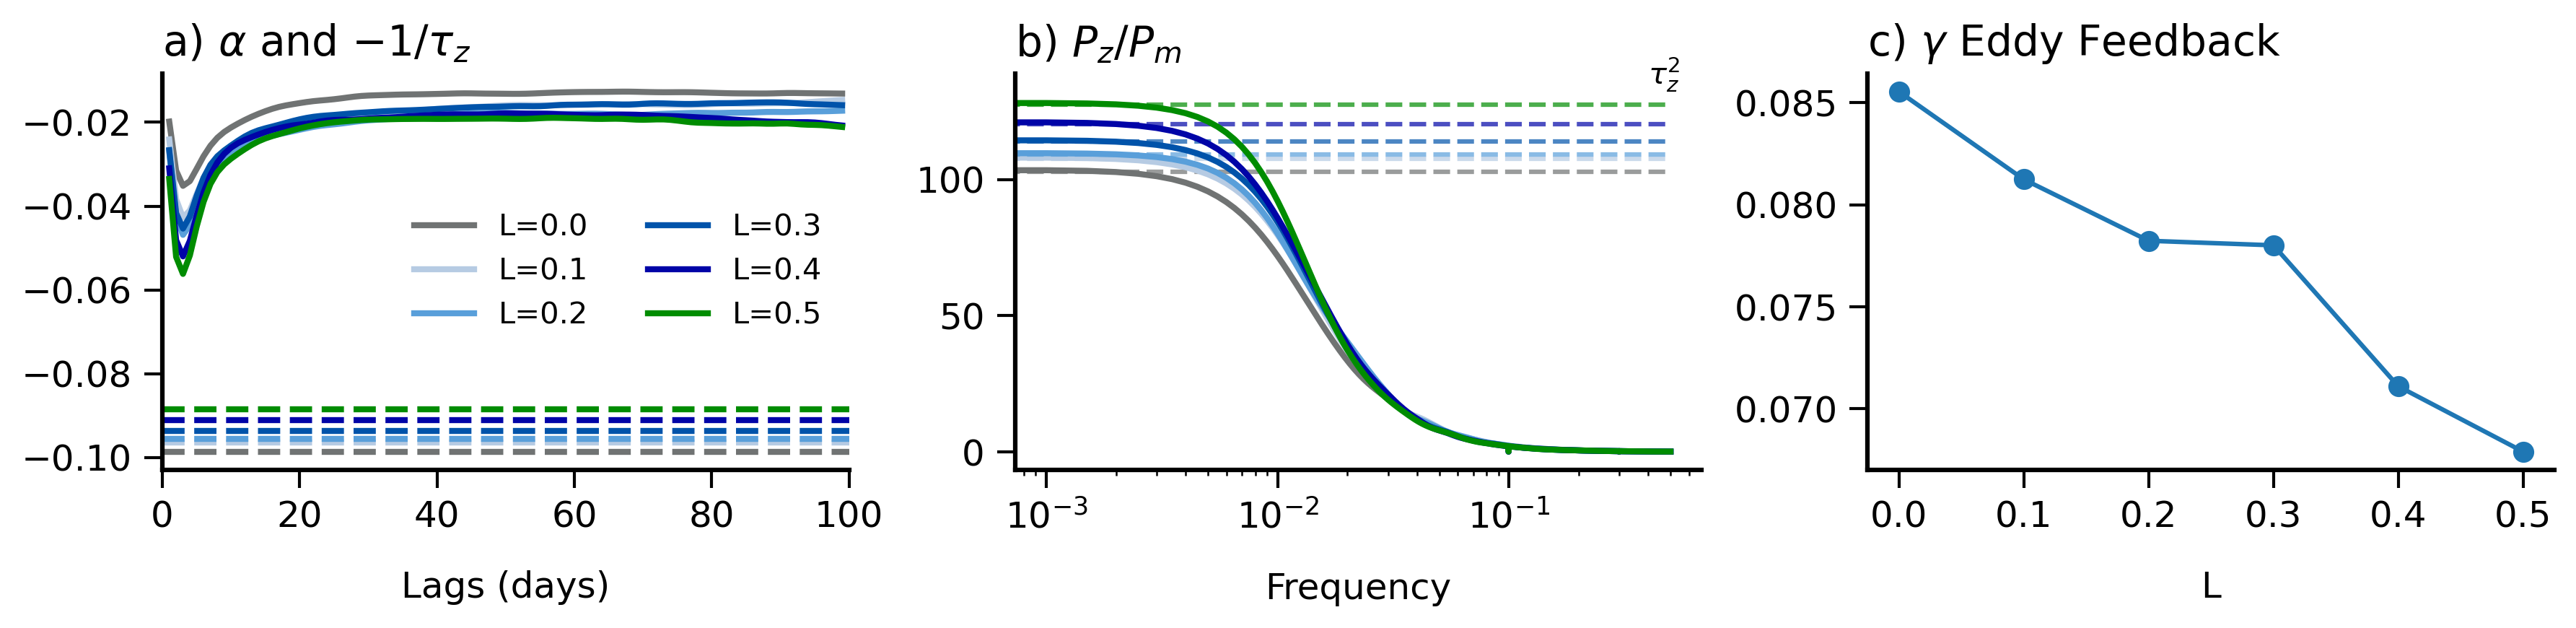

In [176]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
from scipy.ndimage import gaussian_filter1d

# Parameters
num_exp = 6
num_lat = 32
lg = 2000  # Length of the interval
overlap = 1000  # Overlap between windows
colors = np.array([[112, 115, 115], [182, 203, 227], [89, 159, 218], 
                   [0, 83, 170], [0, 4, 167], [0, 140, 1]]) / 255.0

# Placeholder for results
tau_z_square = np.zeros(num_exp)
m_fig3 = np.zeros((num_exp, 19500))
PP_all_u = np.zeros((num_exp, 19500))
total_L = np.zeros((num_exp, 100))
total_L_final = np.zeros(num_exp)
fig4_final = np.zeros(num_exp)
take_min_day = 90  #40
take_max_day = 100 #60
take_len_day = take_max_day - take_min_day

# Helper functions
def compute_running_mean(data, window_size):
    """Compute running mean for smoothing."""
    cumsum = np.cumsum(np.insert(data, 0, 0))
    return (cumsum[window_size:] - cumsum[:-window_size]) / float(window_size)

def compute_fft_cross_spectrum(signal1, signal2, lg, overlap):
    """Compute FFT-based cross-spectrum for two signals."""
    Pz_all = np.zeros(lg, dtype=np.complex_)
    Pm_all = np.zeros(lg, dtype=np.complex_)
    n_segments = 0

    for i in range(0, len(signal1) - lg + 1, lg - overlap):
        hanning_window = np.hanning(lg)
        Z_segment = fft(signal1[i:i + lg] * hanning_window) / len(hanning_window)
        M_segment = fft(signal2[i:i + lg] * hanning_window) / len(hanning_window)

        Pz_all += Z_segment * np.conjugate(Z_segment)
        Pm_all += M_segment * np.conjugate(M_segment)
        n_segments += 1

    return Pz_all / n_segments, Pm_all / n_segments

# Generate `m_fig3` and `PP_all_u`
for exp_idx in range(num_exp):
    u_weighted = Uzm_all[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5)
    single_EOF_u = EOF((u_weighted,), n_components=num_lat, field="1D")
    single_EOF_u.get()

    PP_all_u[exp_idx] = single_EOF_u.PC[0]
    EOF_u_final = single_EOF_u.EOF[0]
    m_fig3[exp_idx] = np.dot(dmdy[exp_idx, :, num_lat:] * (cy[num_lat:] ** 0.5), EOF_u_final)

# Plot initialization
# fig, ax = plt.subplots(1, 3, figsize=(15, 4), dpi=300)
fig, ax = plt.subplots(1,3, figsize=(12,3), dpi=300.)

import matplotlib as mpl

mpl.rcParams['axes.linewidth'] = 1.5

# Compute cross-spectrum and plot for each experiment
for exp_idx in range(num_exp):
    Pz_all, Pm_all = compute_fft_cross_spectrum(PP_all_u[exp_idx], m_fig3[exp_idx], lg, overlap)
    freq = np.fft.fftfreq(lg)
    spectrum = Pz_all / Pm_all / (86400**2)

    # Smooth spectrum for better visualization
    tau_smoothed = compute_running_mean(spectrum.real, 5)
    freq_smoothed = compute_running_mean(freq, 5)
    spectrum_gaussian = gaussian_filter1d(tau_smoothed, sigma=8)
    sorted_idx = np.argsort(freq_smoothed)

    # Plot smoothed spectrum
    ax[1].plot(freq_smoothed[sorted_idx], spectrum_gaussian[sorted_idx], 
               label=f"L={exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)

    # Compute and plot tau_z_square
    tau_z_square[exp_idx] = spectrum_gaussian[sorted_idx][lg//2:lg//2+10].max()
    ax[1].hlines(tau_z_square[exp_idx], xmin=freq_smoothed[sorted_idx].min(), 
                 xmax=freq_smoothed[sorted_idx].max(), linestyle="--", color=colors[exp_idx], alpha=0.7)

# Compute logarithmic derivative for Fig. 3(a)
for exp_idx in range(num_exp):
    autocorr_data = autocorr_results[exp_idx]  # Use the provided autocorrelation results in Fig.1
    for i in range(1, 100):
        total_L[exp_idx, i] = np.log(autocorr_data[100 + i]) / i

    total_L_final[exp_idx] = np.mean(total_L[exp_idx, take_min_day:take_max_day])

    ax[0].plot(range(1, 100), total_L[exp_idx, 1:], label=f"L={exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=2)
    ax[0].axhline(-1 / (tau_z_square[exp_idx] ** 0.5), linestyle="--", color=colors[exp_idx], lw=2)

# Calculate feedback differences for Fig. 3(c)
for exp_idx in range(num_exp):
    fig4_final[exp_idx] = np.median(total_L[exp_idx, take_min_day:take_max_day]) - (-1 / tau_z_square[exp_idx]**0.5)

# Plot feedback differences
L_values = np.arange(0, 0.6, 0.1)
ax[2].scatter(L_values, fig4_final)
ax[2].plot(L_values, fig4_final)

# Final plot customizations
ax[0].set_title(r"a) $\alpha$ and $-1/\tau_z$", loc="left", fontsize=14)
ax[0].set_xlabel("Lags (days)", fontsize=12 , labelpad=12)
ax[0].set_xlim([0, 100])
ax[0].legend(loc = 0, prop={'size': 10},frameon=False, ncols=2)

ax[1].set_title(r"b) $P_z / P_m$", loc="left", fontsize=14)
ax[1].set_xlabel("Frequency", fontsize=12 , labelpad=12)
ax[1].text(0.4, 135, r"$\tau ^2 _{z}$")
ax[1].set_xscale("log")

ax[2].set_title(r"c) $\gamma$ Eddy Feedback", loc="left", fontsize=14)
ax[2].set_xlabel("L", fontsize=12 , labelpad=12)

for i in range(3):
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["top"].set_visible(False)
    ax[i].tick_params(axis='x', labelsize=12, pad=4)
    ax[i].tick_params(axis='y', labelsize=12, pad=4)
    ax[i].tick_params(direction='out', length=6, width=1)

plt.tight_layout()
plt.show()


In [177]:
m_fig3.shape

(6, 19500)

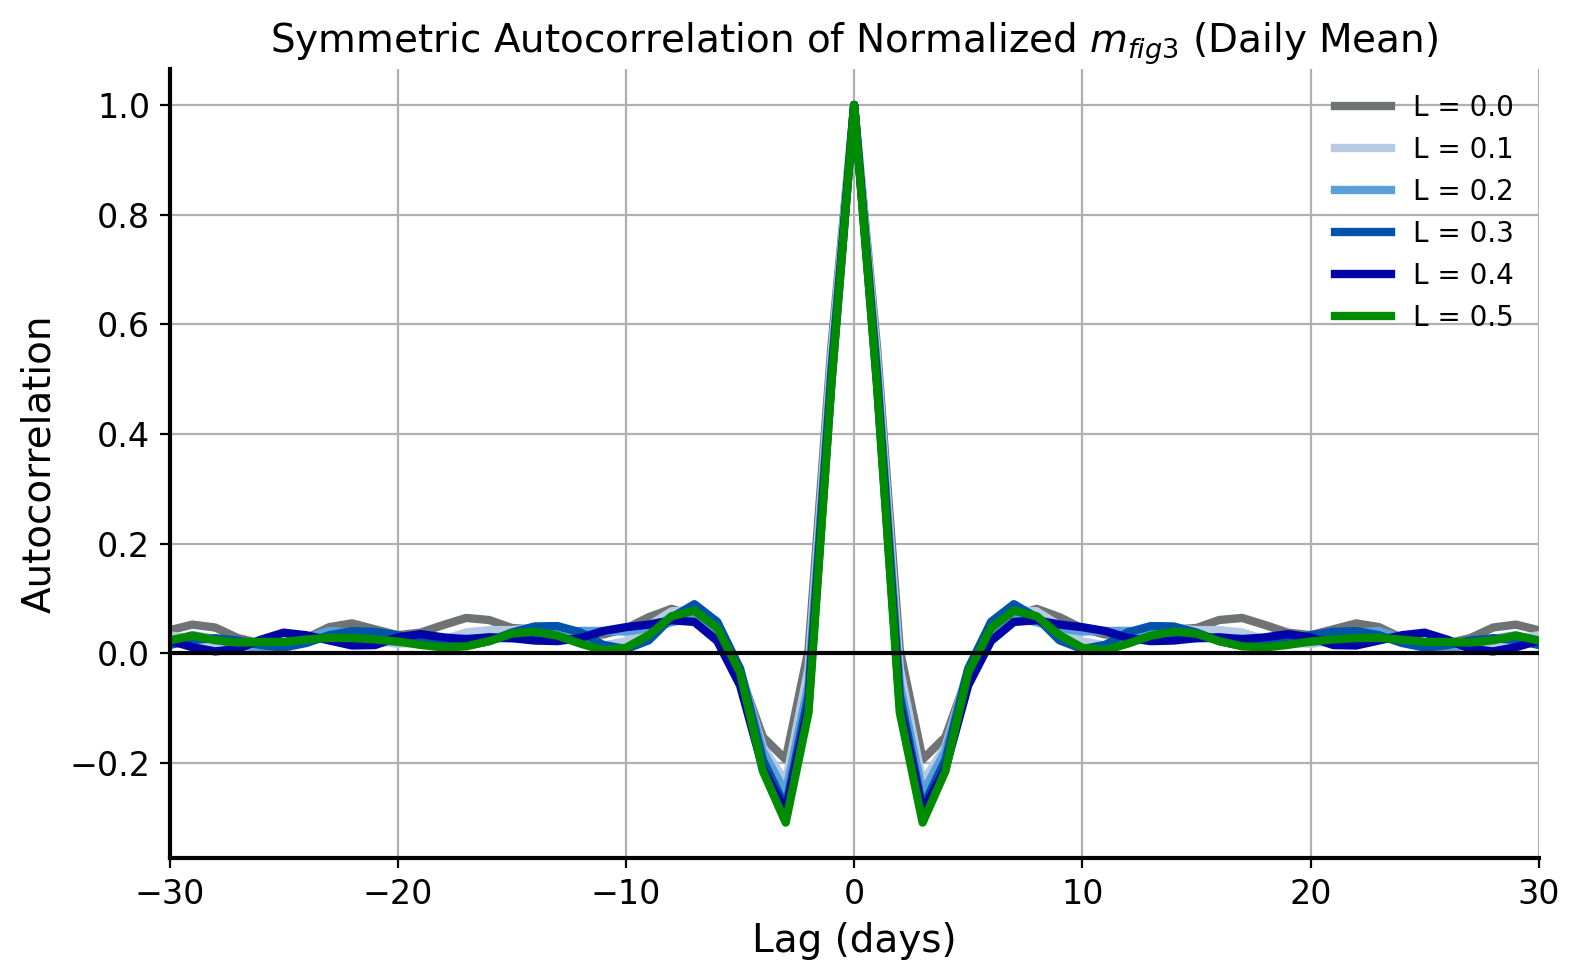

In [178]:
# Normalize `m_fig3` before autocorrelation
m_fig3_normalized = np.zeros_like(m_fig3)
for exp_idx in range(num_exp):
    m_mean = np.mean(m_fig3[exp_idx])
    m_std = np.std(m_fig3[exp_idx])
    m_fig3_normalized[exp_idx] = (m_fig3[exp_idx] - m_mean) / m_std

split_to_chunk = True

# Calculate autocorrelation for normalized `m_fig3`
autocorr_m_fig3_results = []
for exp_idx in range(num_exp):
    autocorr_m_fig3_results.append(
        moist_dycore.symmetric_autocorr(m_fig3_normalized[exp_idx], auto_length, split_to_chunk, window_length)
    )

# Plot the symmetric autocorrelation for normalized m_fig3
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=200)
mpl.rcParams['axes.linewidth'] = 1.5

for exp_idx in range(num_exp):
    ax.plot(tau_full, autocorr_m_fig3_results[exp_idx], 
            label=f"L = {exp_idx * 0.1:.1f}", color=colors[exp_idx], lw=3)

# Customize plot for normalized m_fig3 autocorrelation
ax.set_title("Symmetric Autocorrelation of Normalized $m_{fig3}$ (Daily Mean)", fontsize=14)
ax.set_xlabel("Lag (days)", fontsize=14)
ax.set_ylabel("Autocorrelation", fontsize=14)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.xlim([-30, 30])
plt.legend(loc="best", fontsize=10, frameon=False)
plt.hlines(y=0, xmin=-100,xmax=100, lw=1.5, color="Black")

plt.grid()
plt.tight_layout()
plt.show()


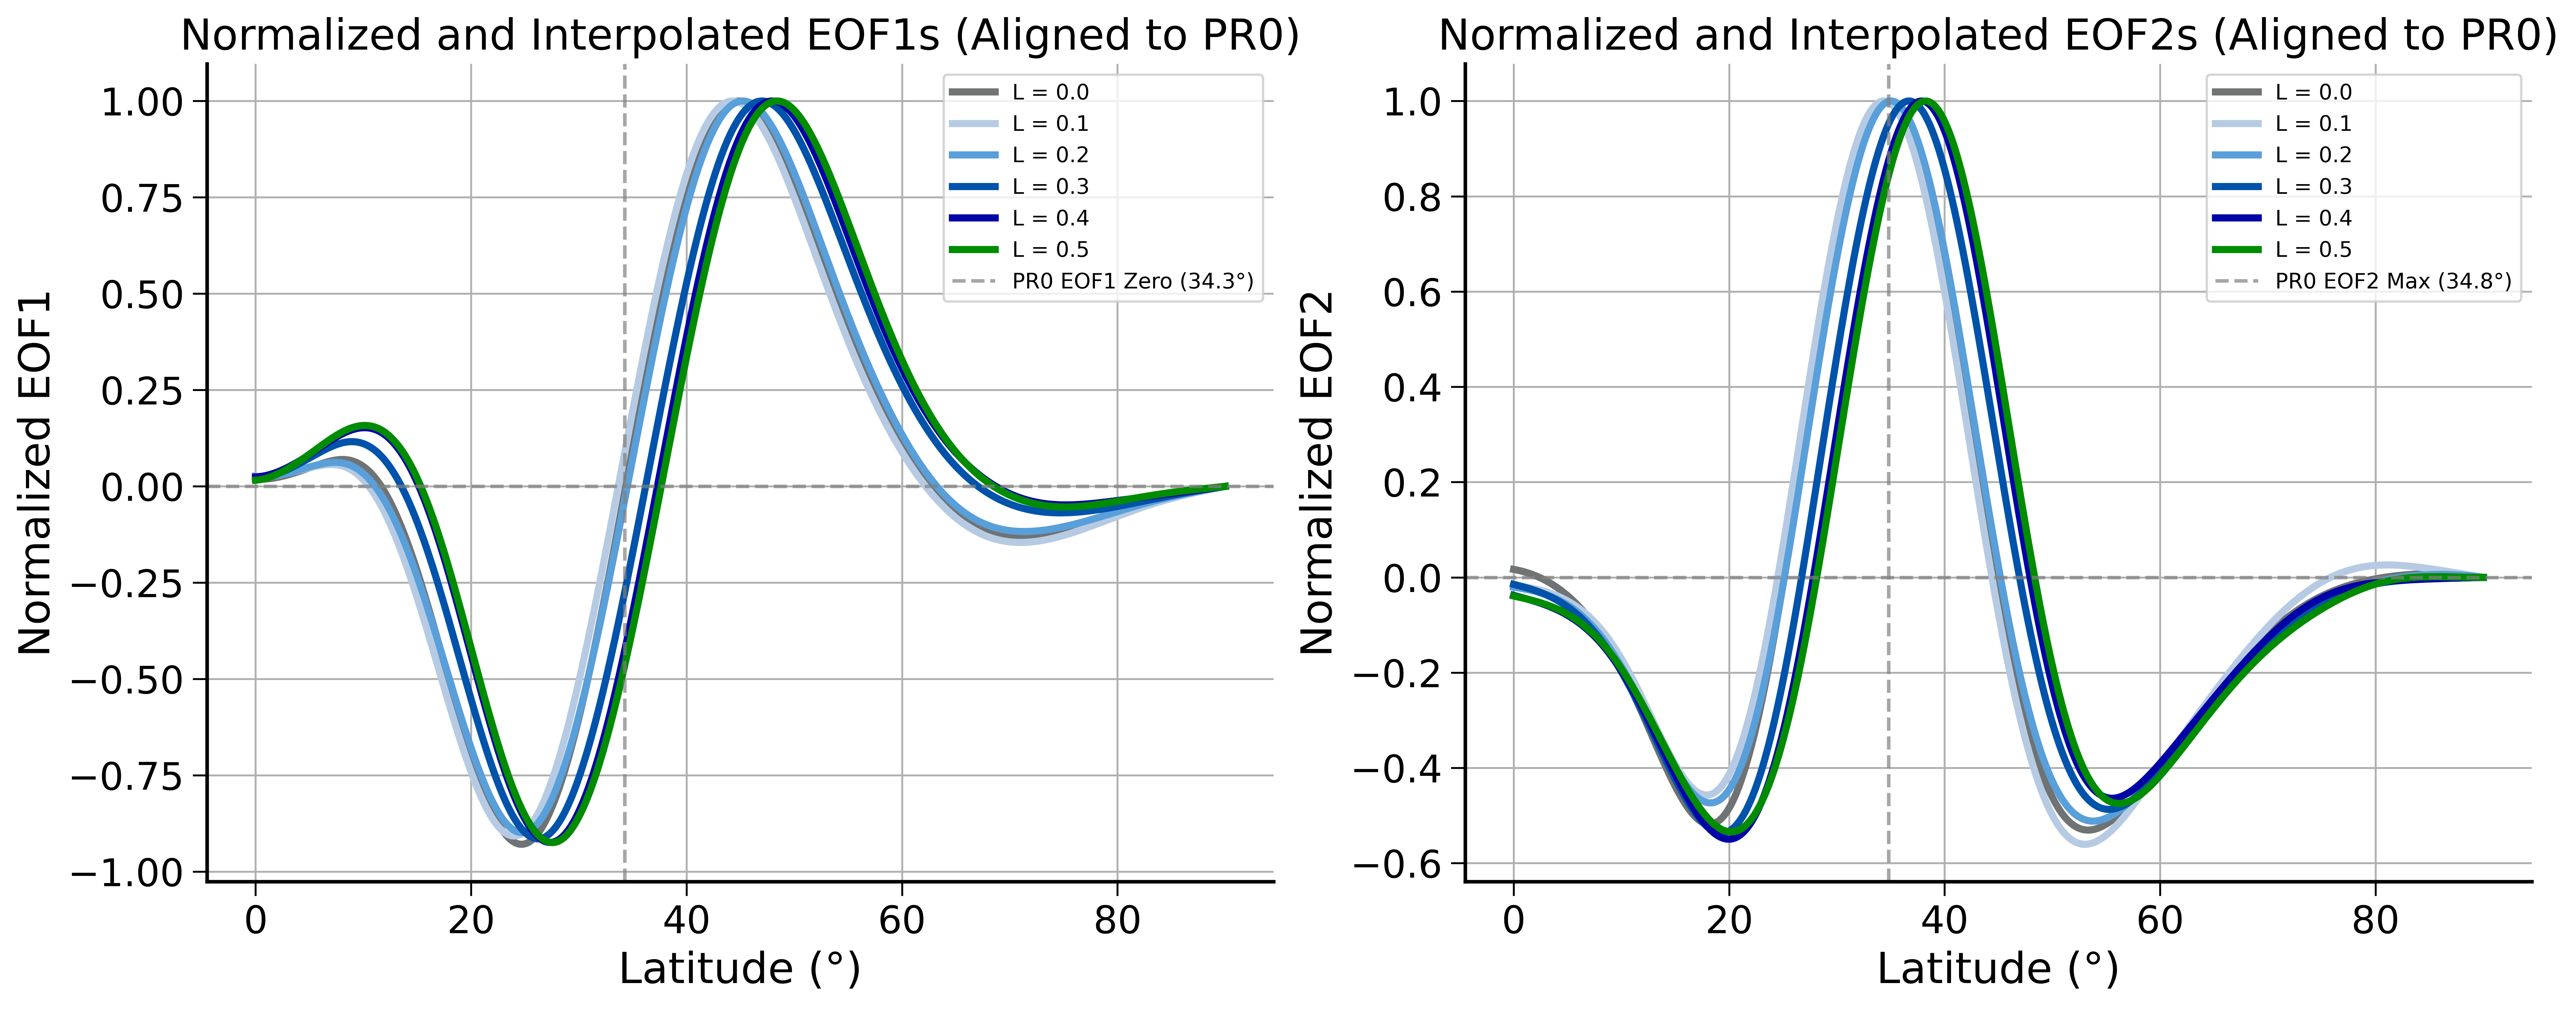

In [179]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

# Initialize variables
new_x = np.linspace(0, 90, 500)  # Finer grid for interpolation

EOF1_all = EOFs_all[:, 0, :]  # Extract EOF1
EOF2_all = EOFs_all[:, 1, :]  # Extract EOF2

# Reference EOFs for PR0 (will be interpolated first)
x = np.linspace(0, 90, 32)  # Original latitude grid
EOF1_ref_interp = interp1d(x, EOF1_all[0], kind="cubic")(new_x)
EOF2_ref_interp = interp1d(x, EOF2_all[0], kind="cubic")(new_x)

# Normalize PR0's EOFs
EOF1_ref_interp /= np.max(np.abs(EOF1_ref_interp))
EOF2_ref_interp /= np.max(np.abs(EOF2_ref_interp))

# Find the latitude where PR0's EOF1 crosses zero in the range 20° to 40°
lat_range_mask = (new_x >= 20) & (new_x <= 40)
zero_crossing_idx = np.where(np.diff(np.sign(EOF1_ref_interp[lat_range_mask])))[0]
EOF1_zero_cross_lat = new_x[lat_range_mask][zero_crossing_idx[0]]

# Find the latitude of the maximum absolute value of PR0's EOF2
EOF2_max_lat = new_x[np.argmax(np.abs(EOF2_ref_interp))]

# Create figure and subplots
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# Process and plot EOF1
for i in range(6):
    # Interpolate EOF1
    interpolated_data = interp1d(x, EOF1_all[i], kind="cubic")(new_x)

    # Normalize and align sign
    interpolated_data /= np.max(np.abs(interpolated_data))  # Normalize
    if np.dot(interpolated_data, EOF1_ref_interp) < 0:  # Align sign with PR0's EOF1
        interpolated_data = -interpolated_data

    # Plot EOF1
    axs[0].plot(new_x, interpolated_data, label=f"L = {i * 0.1:.1f}", color=colors[i], lw=3)

# Add horizontal line at 0 and vertical line at zero-crossing latitude for EOF1
axs[0].axhline(0, linestyle="--", color="gray", alpha=0.7)
axs[0].axvline(EOF1_zero_cross_lat, linestyle="--", color="gray", alpha=0.7, label=f"PR0 EOF1 Zero ({EOF1_zero_cross_lat:.1f}°)")

# Customize EOF1 plot
axs[0].set_title("Normalized and Interpolated EOF1s (Aligned to PR0)", fontsize=18)
axs[0].set_ylabel("Normalized EOF1", fontsize=18)
axs[0].legend(fontsize=9)

# Process and plot EOF2
for i in range(6):
    # Interpolate EOF2
    interpolated_data = interp1d(x, EOF2_all[i], kind="cubic")(new_x)

    # Normalize and align sign
    interpolated_data /= np.max(np.abs(interpolated_data))  # Normalize
    if np.dot(interpolated_data, EOF2_ref_interp) < 0:  # Align sign with PR0's EOF2
        interpolated_data = -interpolated_data

    # Plot EOF2
    axs[1].plot(new_x, -interpolated_data, label=f"L = {i * 0.1:.1f}", color=colors[i], lw=3)

# Add horizontal line at 0 and vertical line at maximum latitude for EOF2
axs[1].axhline(0, linestyle="--", color="gray", alpha=0.7)
axs[1].axvline(EOF2_max_lat, linestyle="--", color="gray", alpha=0.7, label=f"PR0 EOF2 Max ({EOF2_max_lat:.1f}°)")

# Customize EOF2 plot
axs[1].set_title("Normalized and Interpolated EOF2s (Aligned to PR0)", fontsize=18)
axs[1].set_ylabel("Normalized EOF2", fontsize=18)
axs[1].legend(fontsize=9)

# Finalize and show the plot
for i in range(2):
    axs[i].spines["right"].set_visible(False)
    axs[i].spines["top"].set_visible(False)
    axs[i].set_xlabel("Latitude (°)", fontsize=18)
    axs[i].tick_params(axis='x', labelsize=16)
    axs[i].tick_params(axis='y', labelsize=16)
    axs[i].tick_params(direction='out', length=6)
    axs[i].grid()
# Adjust layout and show
plt.tight_layout()
plt.show()


In [180]:
def cross_corr_chunked(x, y, lag_max, chunk_size, overlap_size):
    """
    Calculate the cross-correlation between two signals x and y, using overlapping chunks.

    Parameters:
    x, y: Input signals to calculate cross-correlation.
    lag_max: Maximum number of lags to compute.
    chunk_size: Size of each chunk (default is 128).
    overlap_size: Number of points to overlap between chunks (default is 64).

    Returns:
    lags: Array of lag values.
    mean_corr: Averaged cross-correlation across all chunks.
    """
    step_size = chunk_size - overlap_size
    num_chunks = (len(x) - overlap_size) // step_size  # Number of chunks with overlap
    print(num_chunks)
    corr_matrix = np.zeros((num_chunks, 2 * lag_max + 1))  # Store cross-correlation for each chunk

    for i in range(num_chunks):
        start = i * step_size
        end = start + chunk_size

        if end > len(x) or end > len(y):  # Avoid going beyond the signal length
            break

        # Extract the chunk from x and y
        x_chunk = x[start:end]
        y_chunk = y[start:end]

        # Compute the cross-correlation for the current chunk        
        corr = np.correlate(x_chunk-np.mean(x_chunk), y_chunk-np.mean(y_chunk), mode='full')
        mid  = len(corr) // 2
        chunk_corr = corr[mid-lag_max:mid+lag_max+1] / (len(x_chunk) * np.std(x_chunk) * np.std(y_chunk))

        # Store the chunk correlation
        corr_matrix[i, :] = chunk_corr

    # Average the cross-correlation across all chunks
    mean_corr = np.mean(corr_matrix, axis=0)
    lags = np.arange(-lag_max, lag_max + 1)

    return lags, mean_corr

In [181]:
PC1_all.shape

(6, 19500)

In [182]:
m_fig3_normalized.shape

(6, 19500)

303
303
303
303
303
303


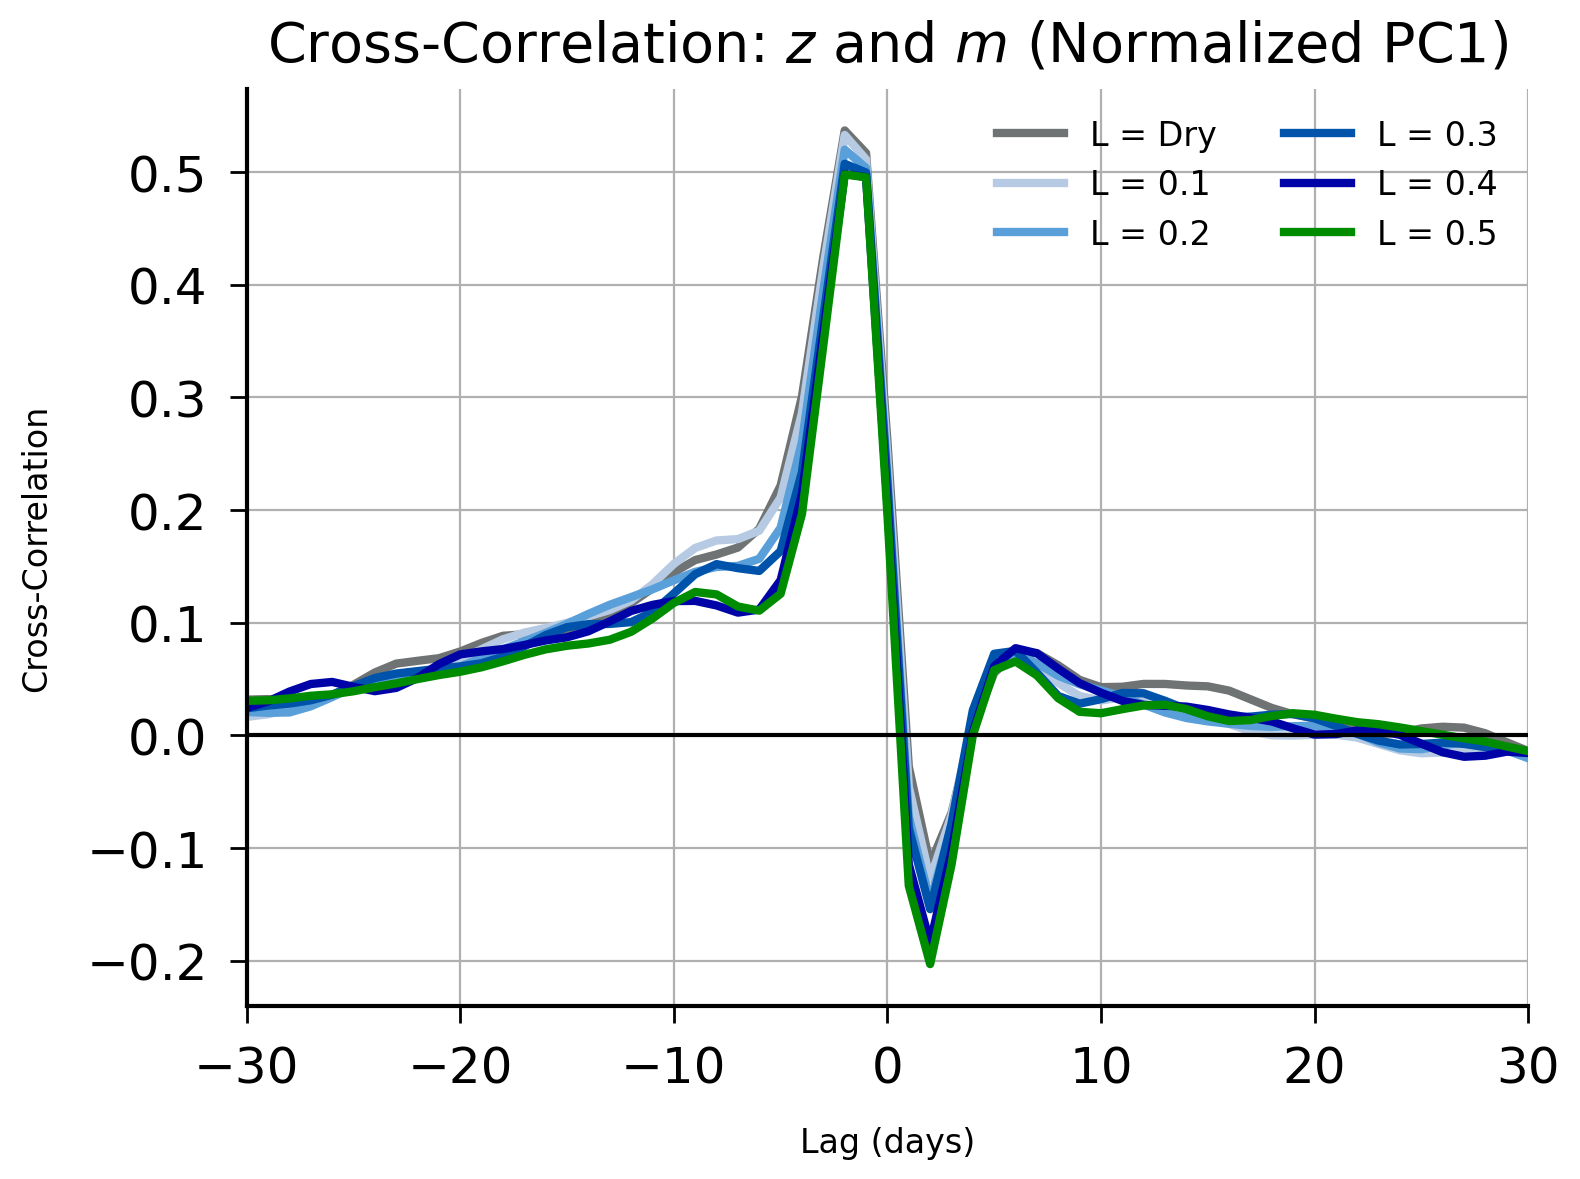

In [183]:
# Normalize PC1_all before computing cross-correlation
PC1_all_normalized = []
for pc1 in PC1_all:
    normalized_pc1 = (pc1 - np.mean(pc1)) / np.std(pc1)
    PC1_all_normalized.append(normalized_pc1)
PC1_all_normalized = np.array(PC1_all_normalized)

# Plot Cross-Correlation between normalized `PC1` and `m_fig3`
fig, ax = plt.subplots(1, figsize=(8, 6), dpi=200)

# Constants
radius = 6.37122e6

auto_length = 100
chunk_size = 128  # Set your chunk size here
overlap_size = 64  # Set your overlap size here

mpl.rcParams['axes.linewidth'] = 2

# Loop over each PR value to compute and plot cross-correlation
for idx, PR in enumerate(PR_values):
    # Calculate cross-correlation with chunking and overlap
    lags, cross_corr_values = cross_corr_chunked(
        m_fig3_normalized[idx], PC1_all_normalized[idx], auto_length, chunk_size, overlap_size
    )

    # Plot the cross-correlation
    label = "L = Dry" if PR == 0 else f"L = {PR * 0.01}"
    ax.plot(lags, cross_corr_values, label=label, color=colors[idx], lw=3)

# Customize plot appearance
ax.set_title("Cross-Correlation: $z$ and $m$ (Normalized PC1)", fontsize=20, pad=10)
ax.set_xlabel("Lag (days)", fontsize=12, labelpad=12)
ax.set_ylabel("Cross-Correlation", fontsize=12, labelpad=12)
ax.legend(loc="best", prop={"size": 12}, frameon=False, ncols=2)

# Add horizontal line at y=0
ax.axhline(y=0, color="black", linestyle="-", linewidth=1.5)

# Set axis limits and ticks
ax.set_xlim([-30, 30])
ax.tick_params(axis="x", labelsize=18, pad=8)
ax.tick_params(axis="y", labelsize=18, pad=8)
ax.tick_params(direction="out", length=6, width=1)

# Remove unnecessary spines
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

# Add grid and finalize layout
ax.grid()
plt.tight_layout()

# Show the plot
plt.show()


In [184]:
def Cal_EOF_PC2(input_data):
    from EOF import EOF
    
    input_data_weighted = input_data * np.sqrt(np.cos(np.deg2rad(np.linspace(0, 90, input_data.shape[1]))))
    n_component = min(input_data.shape[0], input_data.size // input_data.shape[0])

    eof_instance = EOF((input_data_weighted,), n_components=n_component, field="1D")
    eof_instance.get()

    EOF1, EOF2 = eof_instance.EOF[:2]
    PC1, PC2 = eof_instance.PC[:2]

    PC1_norm, PC2_norm = (PC1 - PC1.mean()) / PC1.std(), (PC2 - PC2.mean()) / PC2.std()
    EOF1_norm, EOF2_norm = EOF1 * PC1.std(), EOF2 * PC2.std()
    
    return EOF1 *  PC1.std(), PC1 / PC1.std()

270
270
270
270
270
270
270
270
270
270
270
270


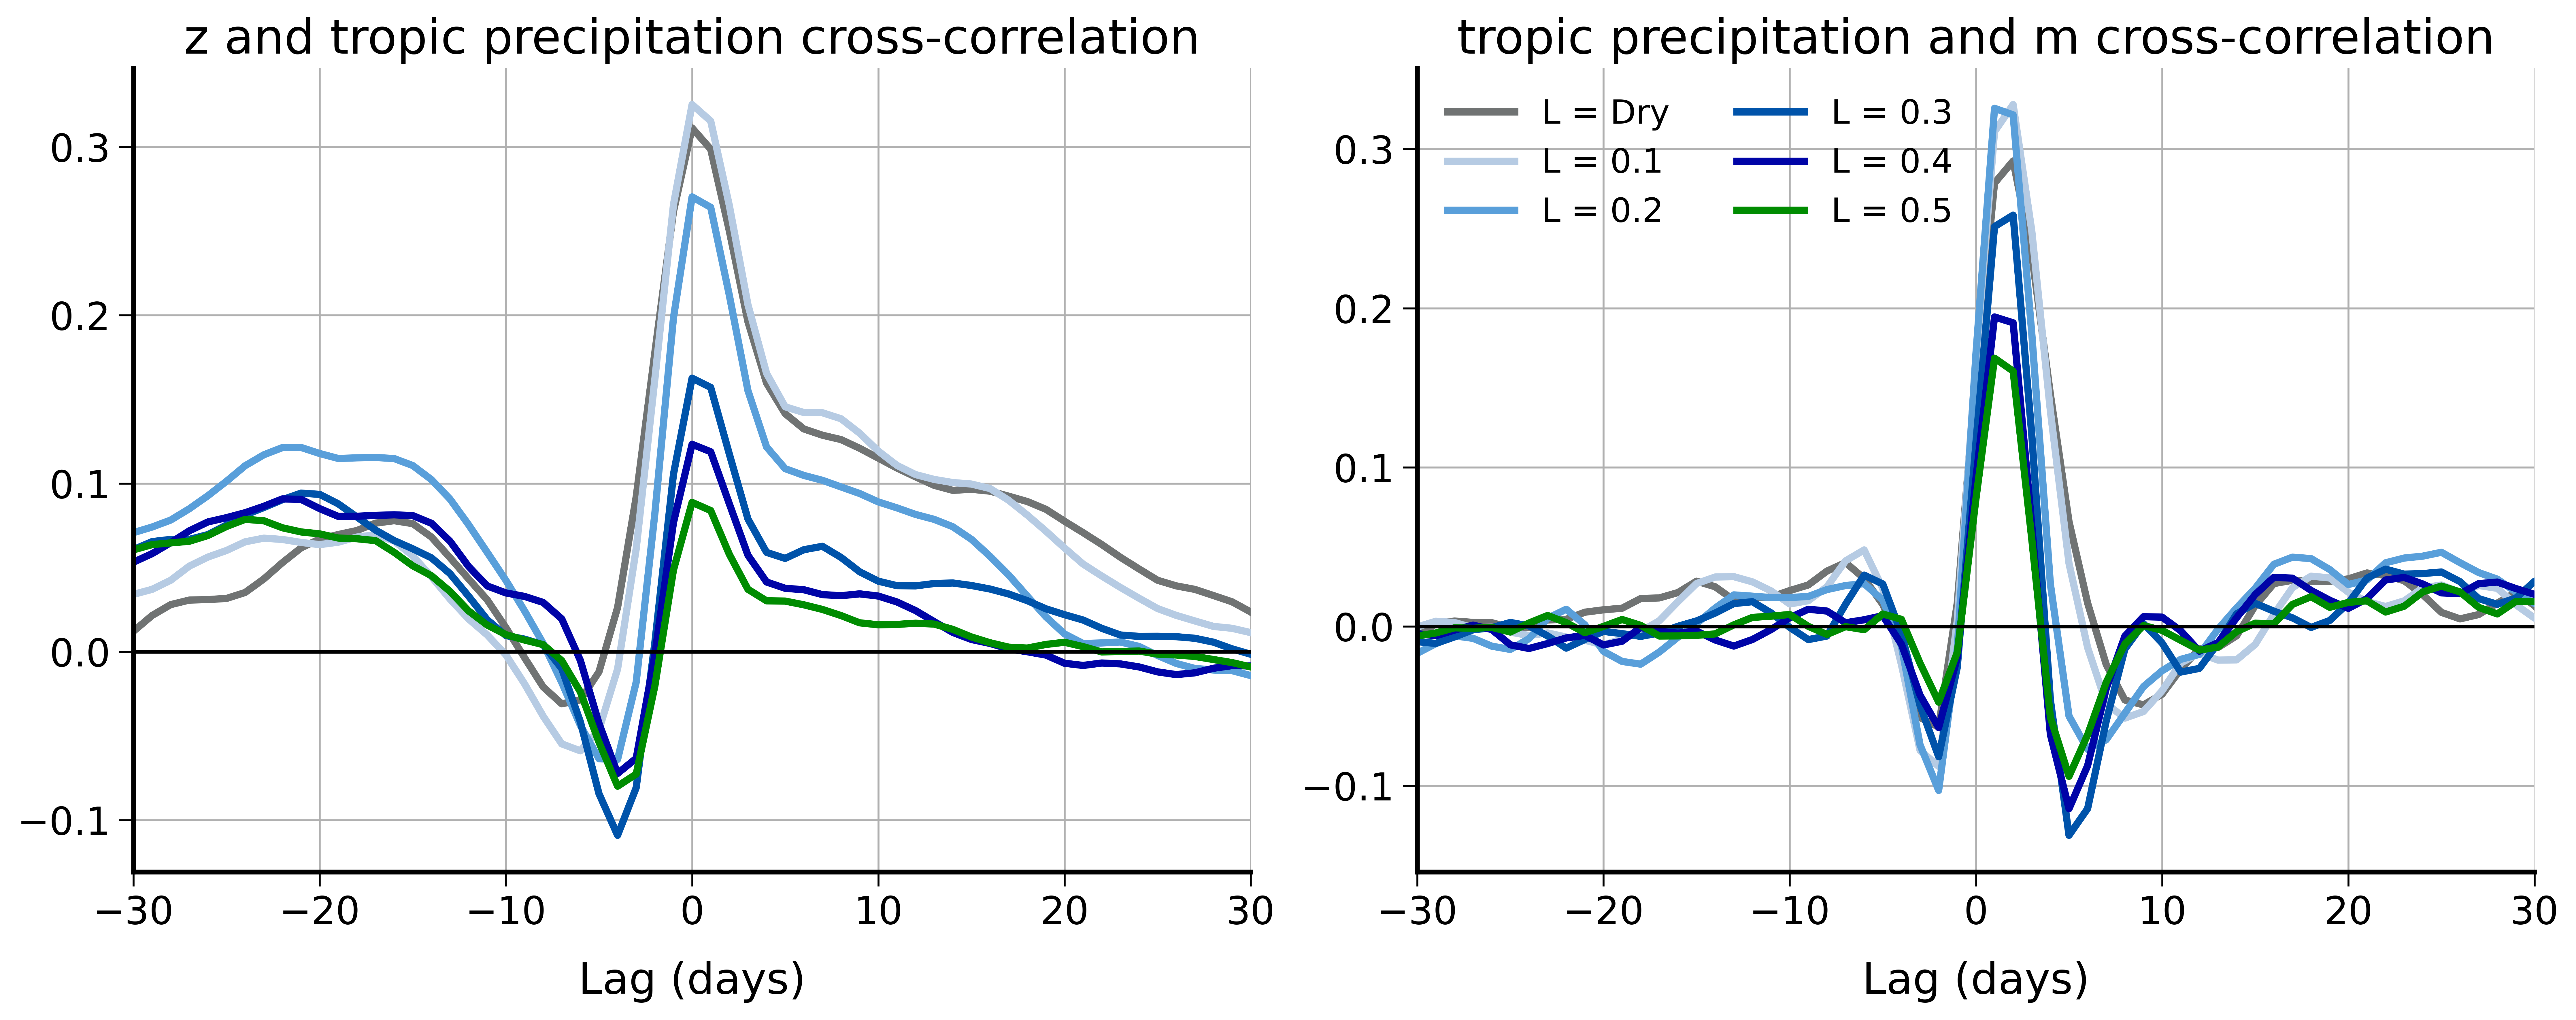

In [139]:
import matplotlib as mpl

# Main loop to compute cross-correlation of m and PC1 with chunking and overlap
fig, ax = plt.subplots(1,2, figsize=(15, 6), dpi=600.)
# Constants
radius = 6.37122e6
y = np.linspace(-90, 90, 64)
yd = np.deg2rad(y)
cy = np.cos(yd)
PR_values = range(0, 60, 10)  # PR values from 0 to 50
mpl.rcParams['axes.linewidth'] = 2

for idx, PR in enumerate(PR_values):
    # Load EMF and u data
    emf_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/Mean_6hourly_to_daily_mean/PR{PR}/EMF/PR{PR}_500_20000day_EMF_zonal_mean_daily.dat"
    with h5py.File(emf_file, "r") as u_file0:
        EMF = np.asarray(u_file0["EMF"][:,:,:]).mean(axis=1)

    u_file = f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/Mean_6hourly_to_daily_mean/PR{PR}/u/PR{PR}_500_20000day_u_zonal_mean_daily.dat"
    with h5py.File(u_file, "r") as u_file0:
        u = np.asarray(u_file0["u"][:,:,:]).mean(axis=1)
        
    with h5py.File(f"/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR{PR}/prec/PR{PR}_500_20000day_6hourly_prec_0_600hPa_sum.dat"
    ) as f:
        prec = f["prec"][:, 32:40]

    num_days = prec.shape[0] // 4  # Ensure divisible by 4
    prec_daily = prec[:num_days * 4].reshape(num_days, 4, *prec.shape[1:]).mean(axis=1)
    
    prec_daily *= 86400
    prec_daily_zm = prec_daily.mean(axis=2)
    prec_daily_zm_ym = np.mean(prec_daily_zm, axis=1)
    
    # Calculate EOF and PC
    EOF1, PC1           = Cal_EOF_PC2(u[:,32:])
    # EOF1_prec, PC1_prec = Cal_EOF_PC2(prec_daily_zm[:,:])

    # Prepare data for cross-correlation
    dmdy = np.zeros((19500, 64))
    Mzm = EMF
    
    for i in range(1, 64-1):
        dmdy[:,i] = -(Mzm[:,i+1] * (cy[i]**2) - Mzm[:,i-1]* (cy[i]**2)) / (radius * (cy[i]**2) * (yd[i+1] - yd[i-1]))
    dmdy[:,0] = -(Mzm[:,1]* (cy[1]**2) - Mzm[:,0]* (cy[1]**2)) / (radius * cy[1]**2 *(yd[1] - yd[0]))
    dmdy[:,-1] = -(Mzm[:,-1]* (cy[i]**2) - Mzm[:,-2]* (cy[i]**2)) / (radius * cy[i]**2 *(yd[-1] - yd[-2]))

    m = EOF1.dot(dmdy[:,32:].T) / (EOF1.dot(EOF1.T))
    
    m_final = (m - m.mean()) / m.std()
    PC1_final = (PC1 - PC1.mean()) / PC1.std()

    prec_daily_zm_ym_final = (prec_daily_zm_ym - prec_daily_zm_ym.mean()) / prec_daily_zm_ym.std()
    

    # Set the parameters for chunking and overlap
    auto_length = 100
    chunk_size =  128 # 128  # Set your chunk size here
    overlap_size = 56 # 64  # Set your overlap size here
    
    # Calculate cross-correlation between PC1 and m with chunking and overlap
    lags, cross_corr_values           = cross_corr_chunked(PC1_final, prec_daily_zm_ym_final, auto_length, chunk_size, overlap_size)
    lags_form, cross_corr_values_form = cross_corr_chunked(prec_daily_zm_ym_final, m_final, auto_length, chunk_size, overlap_size)
    # lags, cross_corr_values = cross_corr_chunked(m_final, PC1_final, auto_length, chunk_size, overlap_size)
    

    # Plot fig1
    if PR == 0:
        ax[0].plot(lags, cross_corr_values, label=f"L = Dry", color=colors[idx], lw=3)
    elif PR == 10:
        ax[0].plot(lags, -cross_corr_values, label=f"L = 0.1", color=colors[idx], lw=3)
    elif PR == 20:
        ax[0].plot(lags, -cross_corr_values, label=f"L = 0.2", color=colors[idx], lw=3)
    else:
        ax[0].plot(lags, cross_corr_values, label=f"L = {PR * 0.01}", color=colors[idx], lw=3)

    # Plot fig2
    if PR == 0:
        ax[1].plot(lags_form, cross_corr_values_form, label=f"L = Dry", color=colors[idx], lw=3)
    elif PR == 10:
        ax[1].plot(lags_form, -cross_corr_values_form, label=f"L = 0.1", color=colors[idx], lw=3)
    elif PR == 20:
        ax[1].plot(lags_form, -cross_corr_values_form, label=f"L = 0.2", color=colors[idx], lw=3)
    else:
        ax[1].plot(lags_form, cross_corr_values_form, label=f"L = {PR * 0.01}", color=colors[idx], lw=3)


        
    

# Finalize and show the plot
for i in range(2):
    ax[i].set_xlabel("Lag (days)", fontsize=12, labelpad=12)
    ax[i].spines["right"].set_visible(False)
    ax[i].spines["top"].set_visible(False)
    ax[i].set_xlabel("Lag (days)", fontsize=18)
    ax[i].tick_params(axis='x', labelsize=16)
    ax[i].tick_params(axis='y', labelsize=16)
    ax[i].tick_params(direction='out', length=6)
    ax[i].set_xlim([-30,30])
    ax[i].grid()



# ax.set_title(f"Daily mean data: Cross-correlation of PC1 and m with chunk:{chunk_size} and overlap:{overlap_size}")
ax[0].set_title("z and tropic precipitation cross-correlation", fontsize = 20)
ax[1].set_title("tropic precipitation and m cross-correlation", fontsize = 20)
ax[0].hlines(y=0, xmin=-100,xmax=100, lw=1.5, color="Black")
ax[1].hlines(y=0, xmin=-100,xmax=100, lw=1.5, color="Black")


ax[1].legend(loc="best", prop={'size': 14},frameon=False, ncols=2)

plt.tight_layout()
# plt.savefig(r"/data92/PeterChang/paper1_fig/fig4.png", bbox_inches='tight', dpi=600.)

plt.show()
